# XGBoost 10B-Row Batch Inference Benchmark

Benchmarks `mv.run_batch()` with 10 billion rows of XGBoost inference on CPU. The model is trained on the standard scikit-learn [Wine](https://scikit-learn.org/stable/datasets/toy_dataset.html#wine-recognition-dataset) dataset, and the input rows are those real Wine rows sampled (with replacement) up to scale.

**Prerequisites:**
- `pip install snowflake-ml-python xgboost scikit-learn matplotlib pandas`
- A Snowflake connection configured in `~/.snowflake/connections.toml`
- Permission to create databases, compute pools, and warehouses

**Usage:** Fill in the User Configuration cell below, then Run All.

In [ ]:
# ╔════════════════════════════════════════════════════════════╗
# ║  USER CONFIGURATION — fill these in before running         ║
# ╚════════════════════════════════════════════════════════════╝
CONNECTION_NAME = "<connection>"         # Snowflake connection name (from ~/.snowflake/connections.toml)
DB_NAME = "XGBOOST_BENCHMARK"           # Database to create/use for this benchmark
WAREHOUSE_SIZE = "4X-LARGE"             # Warehouse size for data generation
EVENT_TABLE = "<db>.<schema>.<table>"   # Event table for platform metrics (set to None to skip metrics)

# ╔════════════════════════════════════════════════════════════╗
# ║  BENCHMARK DEFAULTS — change only to explore alternatives  ║
# ╚════════════════════════════════════════════════════════════╝
NUM_NODES = 8
INSTANCE_FAMILY = "CPU_X64_M"
NUM_WORKERS = 5
MAX_BATCH_ROWS = 16_384
REPLICAS = 8
FUNCTION_NAME = "predict"
INPUT_ROWS = 10_000_000_000
GPU_REQUESTS = None                     # Not applicable for CPU workloads
REPEAT = 1
WARMUP_ROW_COUNT = 1_000

MODEL_ID = None                         # Not applicable (model trained locally)
MODEL_NAME = "xgboost_wine_classifier"
MODEL_VERSION = "V1"

In [9]:
if EVENT_TABLE == "<db>.<schema>.<table>":
    EVENT_TABLE = None
    print("EVENT_TABLE not configured -- platform metrics will be skipped.")

WAREHOUSE_NAME = f"{DB_NAME}_WH"
POOL_PREFIX = "BENCHMARK_POOL_XGBOOST"

print(f"Environment: {CONNECTION_NAME} / {DB_NAME}")
print(f"Benchmark: {INPUT_ROWS:,} rows, {REPLICAS} replicas, {NUM_WORKERS} workers, batch={MAX_BATCH_ROWS:,}")
print(f"Compute: {NUM_NODES}x {INSTANCE_FAMILY}")
print(f"Model: {MODEL_NAME}/{MODEL_VERSION}")
print(f"Repeat: {REPEAT}x")

Environment: prod3 / XGBOOST_BENCHMARK
Benchmark: 10,000,000,000 rows, 8 replicas, 5 workers, batch=16,384
Compute: 8x CPU_X64_M
Model: xgboost_wine_classifier/V1
Repeat: 1x


## Session + Setup

In [ ]:
from snowflake.snowpark import Session

session = Session.builder.configs({"connection_name": CONNECTION_NAME}).create()
print(f"Connected: {session.get_current_account()}")

session.sql(f"CREATE DATABASE IF NOT EXISTS {DB_NAME}").collect()
session.sql(f"CREATE SCHEMA IF NOT EXISTS {DB_NAME}.PUBLIC").collect()
session.sql(f"USE DATABASE {DB_NAME}").collect()
session.sql(f"USE SCHEMA PUBLIC").collect()
session.sql(f"CREATE STAGE IF NOT EXISTS BENCHMARK_STAGE ENCRYPTION = (TYPE = 'SNOWFLAKE_SSE')").collect()
session.sql(
    f"CREATE WAREHOUSE IF NOT EXISTS {WAREHOUSE_NAME} WITH WAREHOUSE_SIZE='{WAREHOUSE_SIZE}' AUTO_SUSPEND=60"
).collect()

print("Environment resources ready.")

# --- Train and register XGBoost model ---
from snowflake.ml.registry import registry

reg = registry.Registry(session=session, database_name=DB_NAME, schema_name="PUBLIC")

try:
    mv = reg.get_model(MODEL_NAME).version(MODEL_VERSION)
    print(f"Model already registered: {MODEL_NAME}/{MODEL_VERSION}")
except Exception:
    import pandas as pd
    import xgboost as xgb
    from sklearn.datasets import load_wine
    from sklearn.model_selection import train_test_split

    print("Training XGBoost on Wine dataset...")
    wine = load_wine()
    feature_names = [name.replace("/", "_") for name in wine.feature_names]
    X_train, _, y_train, _ = train_test_split(
        pd.DataFrame(wine.data, columns=feature_names),
        wine.target,
        test_size=0.2,
        random_state=42,
    )

    model = xgb.XGBClassifier(
        n_estimators=100, max_depth=6, learning_rate=0.1,
        random_state=42, tree_method="hist", n_jobs=-1,
    )
    model.fit(X_train, y_train)
    print(f"Training accuracy: {model.score(X_train, y_train):.4f}")

    mv = reg.log_model(
        model,
        model_name=MODEL_NAME,
        version_name=MODEL_VERSION,
        sample_input_data=X_train,
        conda_dependencies=["xgboost", "scikit-learn"],
        options={"enable_explainability": False},
    )
    print(f"Registered: {MODEL_NAME}/{MODEL_VERSION}")

# --- Generate input data from the real Wine dataset ---
# The model is trained on the standard scikit-learn Wine dataset; we load those
# real rows into a small Snowflake table and replicate them up to each target
# row count. XGBoost tree traversal is data-value-independent, so replicating
# real rows (rather than synthesizing values) yields identical throughput while
# keeping the input a recognized standard dataset.
import pandas as pd
from sklearn.datasets import load_wine

WINE_SOURCE_TABLE = "WINE_SOURCE"
wine = load_wine()
feature_names = [name.replace("/", "_") for name in wine.feature_names]

try:
    source_count = session.table(WINE_SOURCE_TABLE).count()
    print(f"{WINE_SOURCE_TABLE} already exists with {source_count:,} rows -- skipping load.")
except Exception:
    wine_df = pd.DataFrame(wine.data, columns=feature_names)
    wine_df.insert(0, "IDX", range(len(wine_df)))
    session.write_pandas(
        wine_df, WINE_SOURCE_TABLE, auto_create_table=True, overwrite=True, quote_identifiers=False
    )
    source_count = len(wine_df)
    print(f"Loaded {source_count:,} real Wine rows into {WINE_SOURCE_TABLE}.")

# Replicate the real rows up to each target row count. UNIFORM(0, K-1, RANDOM())
# samples rows with replacement (inclusive integer bounds, no SEQ4 overflow at
# 10B+), and the small source table is the broadcast side of the join.
feature_cols_sql = ", ".join(f"q.{name}" for name in feature_names)
for row_count in [WARMUP_ROW_COUNT, INPUT_ROWS]:
    table_name = f"WINE_FEATURES_{row_count}"
    try:
        if session.table(table_name).count() >= row_count:
            print(f"{table_name} already exists with enough rows -- skipping.")
            continue
    except Exception:
        pass

    print(f"Generating {table_name} with {row_count:,} rows from {source_count:,} real Wine rows...")
    session.sql(f"""
        CREATE OR REPLACE TABLE {table_name} AS
        SELECT {feature_cols_sql}
        FROM (SELECT UNIFORM(0, {source_count - 1}, RANDOM()) AS IDX
              FROM TABLE(GENERATOR(ROWCOUNT => {row_count}))) g
        JOIN {WINE_SOURCE_TABLE} q ON g.IDX = q.IDX
    """).collect()
    print(f"Created {table_name} with {session.table(table_name).count():,} rows.")

print("Setup complete.")

## Pool + Warmup

In [11]:
import time
import uuid
from snowflake.ml.model.batch import JobSpec, OutputSpec, SaveMode

POOL_NAME = f"{POOL_PREFIX}_{NUM_NODES}N_BENCH"

session.sql(f"DROP COMPUTE POOL IF EXISTS {POOL_NAME}").collect()
session.sql(f"""
    CREATE COMPUTE POOL {POOL_NAME}
    MIN_NODES = {NUM_NODES}
    MAX_NODES = {NUM_NODES}
    INSTANCE_FAMILY = '{INSTANCE_FAMILY}'
    AUTO_SUSPEND_SECS = 3600
""").collect()
print(f"Pool {POOL_NAME} created. Waiting for {NUM_NODES} nodes...")

start = time.time()
while time.time() - start < 1800:
    rows = session.sql(f"DESCRIBE COMPUTE POOL {POOL_NAME}").collect()
    if rows:
        row = rows[0].as_dict()
        state = row.get("state", row.get("STATE", ""))
        active = int(row.get("active_nodes", row.get("ACTIVE_NODES", 0)) or 0)
        idle = int(row.get("idle_nodes", row.get("IDLE_NODES", 0)) or 0)
        if state in ("ACTIVE", "IDLE") and active + idle >= NUM_NODES:
            print(f"Pool ready: {active + idle} nodes, state={state} ({time.time() - start:.0f}s)")
            break
    time.sleep(30)
else:
    raise TimeoutError(f"Pool did not reach {NUM_NODES} nodes within 1800s")

# Warmup run
warmup_name = f"BENCH_{WARMUP_ROW_COUNT // 1000}K_{REPLICAS}R_{uuid.uuid4().hex[:8].upper()}"
warmup_output = f"@{DB_NAME}.PUBLIC.BENCHMARK_STAGE/{warmup_name}/output/"
session.sql(f"REMOVE {warmup_output}").collect()

warmup_df = session.table(f"WINE_FEATURES_{WARMUP_ROW_COUNT}")
print(f"[{warmup_name}] Warmup: {WARMUP_ROW_COUNT:,} rows...")

warmup_start = time.time()
warmup_job = mv.run_batch(
    compute_pool=POOL_NAME,
    X=warmup_df,
    output_spec=OutputSpec(stage_location=warmup_output, mode=SaveMode.OVERWRITE),
    job_spec=JobSpec(
        job_name=warmup_name,
        warehouse=WAREHOUSE_NAME,
        replicas=REPLICAS,
        force_rebuild=True,
        function_name=FUNCTION_NAME,
        num_workers=NUM_WORKERS,
        max_batch_rows=MAX_BATCH_ROWS,
    ),
)
warmup_status = warmup_job.wait(timeout=600)
print(f"Warmup complete: {warmup_status} in {time.time() - warmup_start:.1f}s")

Pool BENCHMARK_POOL_XGBOOST_8N_BENCH created. Waiting for 8 nodes...
Pool ready: 8 nodes, state=IDLE (91s)
[BENCH_1K_8R_F850960C] Warmup: 1,000 rows...


Compute pool busy (8/8 nodes in use, 1 nodes required). Job execution may be delayed.


Warmup complete: DONE in 229.4s


## Benchmark Run

In [12]:
import time
import uuid

results = []
input_table = f"{DB_NAME}.PUBLIC.WINE_FEATURES_{INPUT_ROWS}"


def fetch_server_times(session, job_name, *, retries=12, delay_s=5):
    """Poll GET_JOB_HISTORY until the job row appears with COMPLETED_TIME."""
    for attempt in range(1, retries + 1):
        rows = session.sql(f"""
            SELECT CREATED_TIME, COMPLETED_TIME
            FROM TABLE(SNOWFLAKE.SPCS.GET_JOB_HISTORY(RESULT_LIMIT => 1000))
            WHERE NAME = '{job_name}'
            ORDER BY CREATED_TIME DESC
            LIMIT 1
        """).collect()
        if rows and rows[0]["CREATED_TIME"] and rows[0]["COMPLETED_TIME"]:
            created = rows[0]["CREATED_TIME"]
            completed = rows[0]["COMPLETED_TIME"]
            return (completed - created).total_seconds(), str(created), str(completed)
        print(f"  [{job_name}] GET_JOB_HISTORY not ready (attempt {attempt}/{retries}); retrying in {delay_s}s...")
        time.sleep(delay_s)
    return None, None, None


for i in range(REPEAT):
    job_name = f"BENCH_{INPUT_ROWS // 1000}K_{REPLICAS}R_{uuid.uuid4().hex[:8].upper()}"
    output_location = f"@{DB_NAME}.PUBLIC.BENCHMARK_STAGE/{job_name}/output/"
    session.sql(f"REMOVE {output_location}").collect()

    input_df = session.table(input_table)
    print(f"[{i+1}/{REPEAT}] [{job_name}] Starting: {INPUT_ROWS:,} rows, {REPLICAS} replicas...")

    start = time.time()
    job = mv.run_batch(
        compute_pool=POOL_NAME,
        X=input_df,
        output_spec=OutputSpec(stage_location=output_location, mode=SaveMode.OVERWRITE),
        job_spec=JobSpec(
            job_name=job_name,
            warehouse=WAREHOUSE_NAME,
            replicas=REPLICAS,
            function_name=FUNCTION_NAME,
            num_workers=NUM_WORKERS,
            max_batch_rows=MAX_BATCH_ROWS,
        ),
    )
    print(f"[{job_name}] Job submitted: {job.id}")

    status = job.wait(timeout=7200)
    wall_time = time.time() - start

    server_time, created_time, completed_time = fetch_server_times(session, job_name)
    if server_time is None:
        print(f"  [{job_name}] WARNING: server-side timing unavailable after retries; "
              f"metrics for this run will be skipped.")

    server_throughput = INPUT_ROWS / server_time if server_time else None
    wall_throughput = INPUT_ROWS / wall_time if wall_time > 0 else 0

    results.append({
        "run": i + 1,
        "job_name": job_name,
        "status": status,
        "server_s": round(server_time, 2) if server_time else None,
        "wall_s": round(wall_time, 2),
        "throughput": round(server_throughput) if server_throughput else None,
        "throughput_wall": round(wall_throughput),
        "created_time": created_time,
        "completed_time": completed_time,
    })

    server_str = f"{server_time:.1f}s" if server_time else "n/a"
    tput_str = f"{server_throughput:,.0f}" if server_throughput else "n/a"
    print(f"[{job_name}] {status} | server {server_str} (wall {wall_time:.1f}s) | {tput_str} rows/sec")

print(f"\nCompleted {len(results)} benchmark run(s).")

[1/1] [BENCH_10000000K_8R_44AA8E72] Starting: 10,000,000,000 rows, 8 replicas...
[BENCH_10000000K_8R_44AA8E72] Job submitted: XGBOOST_BENCHMARK.PUBLIC.BENCH_10000000K_8R_44AA8E72
[BENCH_10000000K_8R_44AA8E72] DONE | server 1252.3s (wall 1259.6s) | 7,985,307 rows/sec

Completed 1 benchmark run(s).


## Platform Metrics + Results


--- Run 1: BENCH_10000000K_8R_44AA8E72 ---
  Platform: 650 pts, CPU avg=5.74/max=6.0 cores, Mem avg=18.51/max=24.26 GB


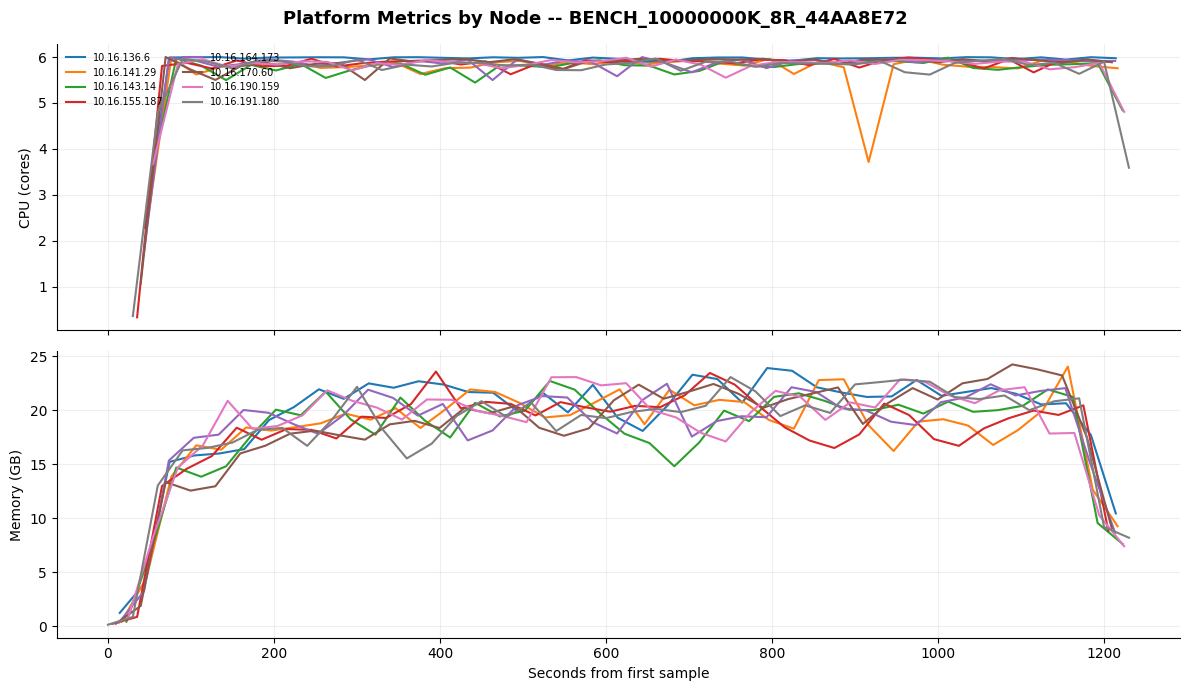

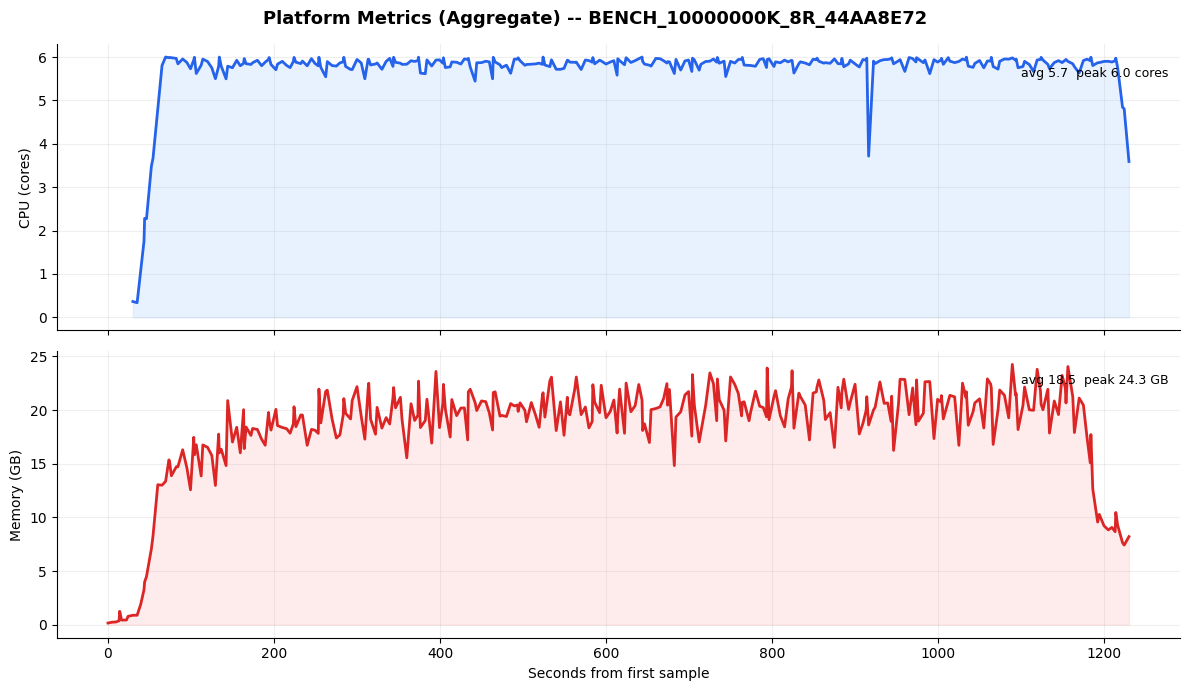


=== Summary ===


,run,job_name,status,wall_s,server_s,throughput,avg_cpu,max_cpu,avg_mem_gb,max_mem_gb
0,1,BENCH_10000000K_8R_44AA8E72,DONE,1259.59,1252.3,7985307,5.74,6.0,18.51,24.26


In [13]:
from collections import defaultdict
from datetime import datetime

import matplotlib.pyplot as plt
import pandas as pd

BYTES_PER_GB = 1024 ** 3


def fetch_platform_metrics(session, event_table, job_name, created_time, completed_time):
    """Query event table for per-node CPU and memory timeseries."""
    query = f"""
        SELECT
            TIMESTAMP,
            RECORD:metric.name::STRING AS metric_name,
            CAST(VALUE AS FLOAT) AS metric_value,
            COALESCE(RESOURCE_ATTRIBUTES:"snow.compute_pool.node.id"::STRING, 'unknown') AS node_id
        FROM {event_table}
        WHERE RESOURCE_ATTRIBUTES:"snow.service.name" = '{job_name}'
          AND SCOPE:"name" = 'snow.spcs.platform'
          AND RECORD_TYPE = 'METRIC'
          AND RECORD:metric.name IN ('container.cpu.usage', 'container.memory.usage')
          AND TIMESTAMP >= DATEADD(minute, -5, CONVERT_TIMEZONE('UTC', '{created_time}'::TIMESTAMP_LTZ)::TIMESTAMP_NTZ)
          AND TIMESTAMP <= DATEADD(minute, 5, CONVERT_TIMEZONE('UTC', '{completed_time}'::TIMESTAMP_LTZ)::TIMESTAMP_NTZ)
        ORDER BY TIMESTAMP, node_id, metric_name
    """
    rows = session.sql(query).collect()
    if not rows:
        print(f"  [{job_name}] No platform metrics yet, retrying in 15s...")
        time.sleep(15)
        rows = session.sql(query).collect()
    if not rows:
        print(f"  [{job_name}] No platform metrics found.")
        return None

    raw_by_node = defaultdict(lambda: defaultdict(lambda: defaultdict(list)))
    raw_cluster = defaultdict(lambda: defaultdict(list))

    for row in rows:
        rd = row.as_dict()
        ts = str(rd.get("TIMESTAMP", rd.get("timestamp")))
        name = rd.get("METRIC_NAME", rd.get("metric_name"))
        raw_val = rd.get("METRIC_VALUE", rd.get("metric_value"))
        if raw_val is None:
            continue
        val = float(raw_val)
        node_id = str(rd.get("NODE_ID", rd.get("node_id", "unknown")))
        raw_by_node[node_id][name][ts].append(val)
        raw_cluster[name][ts].append(val)

    def display_value(name, raw):
        return raw / BYTES_PER_GB if name == "container.memory.usage" else raw

    node_data = {}
    for node_id, metric_map in sorted(raw_by_node.items()):
        node_data[node_id] = {}
        for name, ts_map in metric_map.items():
            series = [
                {"timestamp": ts, "value": display_value(name, sum(samples))}
                for ts, samples in sorted(ts_map.items())
            ]
            node_data[node_id][name] = series

    cluster_data = {}
    for name, ts_map in raw_cluster.items():
        series = [
            {"timestamp": ts, "value": display_value(name, sum(samples))}
            for ts, samples in sorted(ts_map.items())
        ]
        cluster_data[name] = series

    return {"node_data": node_data, "cluster_data": cluster_data, "data_points": len(rows)}


def relative_seconds(points, origin=None):
    if not points:
        return [], []
    timestamps = [datetime.fromisoformat(p["timestamp"]) for p in points]
    base = origin or timestamps[0]
    return [(ts - base).total_seconds() for ts in timestamps], [p["value"] for p in points]


def find_origin(*series_list):
    timestamps = [
        datetime.fromisoformat(s[0]["timestamp"])
        for s in series_list if s and s[0].get("timestamp")
    ]
    return min(timestamps) if timestamps else None


def plot_per_node(metrics, job_name):
    node_data = metrics["node_data"]
    all_series = [s for nd in node_data.values() for s in nd.values()]
    origin = find_origin(*all_series)

    fig, (ax_cpu, ax_mem) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
    fig.suptitle(f"Platform Metrics by Node -- {job_name}", fontsize=13, fontweight="bold")

    for node_id in sorted(node_data):
        cpu_series = node_data[node_id].get("container.cpu.usage", [])
        if cpu_series:
            t, v = relative_seconds(cpu_series, origin)
            ax_cpu.plot(t, v, linewidth=1.5, label=node_id)

        mem_series = node_data[node_id].get("container.memory.usage", [])
        if mem_series:
            t, v = relative_seconds(mem_series, origin)
            ax_mem.plot(t, v, linewidth=1.5, label=node_id)

    ax_cpu.set_ylabel("CPU (cores)")
    ax_cpu.grid(True, alpha=0.2)
    ax_cpu.legend(loc="upper left", fontsize=7, ncol=2, frameon=False)
    for spine in ["top", "right"]:
        ax_cpu.spines[spine].set_visible(False)
        ax_mem.spines[spine].set_visible(False)

    ax_mem.set_ylabel("Memory (GB)")
    ax_mem.set_xlabel("Seconds from first sample")
    ax_mem.grid(True, alpha=0.2)

    fig.tight_layout()
    plt.show()


def plot_aggregate(metrics, job_name):
    cluster_data = metrics["cluster_data"]
    cpu_series = cluster_data.get("container.cpu.usage", [])
    mem_series = cluster_data.get("container.memory.usage", [])
    origin = find_origin(cpu_series, mem_series)

    fig, (ax_cpu, ax_mem) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
    fig.suptitle(f"Platform Metrics (Aggregate) -- {job_name}", fontsize=13, fontweight="bold")

    if cpu_series:
        t, v = relative_seconds(cpu_series, origin)
        ax_cpu.plot(t, v, color="#2563eb", linewidth=2)
        ax_cpu.fill_between(t, v, color="#bfdbfe", alpha=0.35)
        avg_cpu = sum(v) / len(v)
        max_cpu = max(v)
        ax_cpu.text(
            0.99, 0.92, f"avg {avg_cpu:.1f}  peak {max_cpu:.1f} cores",
            transform=ax_cpu.transAxes, ha="right", va="top", fontsize=9,
        )

    if mem_series:
        t, v = relative_seconds(mem_series, origin)
        ax_mem.plot(t, v, color="#dc2626", linewidth=2)
        ax_mem.fill_between(t, v, color="#fecaca", alpha=0.35)
        avg_mem = sum(v) / len(v)
        max_mem = max(v)
        ax_mem.text(
            0.99, 0.92, f"avg {avg_mem:.1f}  peak {max_mem:.1f} GB",
            transform=ax_mem.transAxes, ha="right", va="top", fontsize=9,
        )

    ax_cpu.set_ylabel("CPU (cores)")
    ax_mem.set_ylabel("Memory (GB)")
    ax_mem.set_xlabel("Seconds from first sample")
    for ax in [ax_cpu, ax_mem]:
        ax.grid(True, alpha=0.2)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    fig.tight_layout()
    plt.show()


# --- Collect metrics and plot for each run ---
for r in results:
    if EVENT_TABLE is None:
        print("Platform metrics skipped (EVENT_TABLE not configured).")
        break
    if not r.get("created_time") or not r.get("completed_time"):
        print(f"Run {r['run']}: no timing data, skipping metrics.")
        continue

    print(f"\n--- Run {r['run']}: {r['job_name']} ---")
    metrics = fetch_platform_metrics(
        session, EVENT_TABLE, r["job_name"], r["created_time"], r["completed_time"],
    )

    if metrics:
        cluster_cpu = metrics["cluster_data"].get("container.cpu.usage", [])
        cluster_mem = metrics["cluster_data"].get("container.memory.usage", [])
        cpu_values = [p["value"] for p in cluster_cpu]
        mem_values = [p["value"] for p in cluster_mem]

        r["avg_cpu"] = round(sum(cpu_values) / len(cpu_values), 2) if cpu_values else None
        r["max_cpu"] = round(max(cpu_values), 2) if cpu_values else None
        r["avg_mem_gb"] = round(sum(mem_values) / len(mem_values), 2) if mem_values else None
        r["max_mem_gb"] = round(max(mem_values), 2) if mem_values else None

        print(
            f"  Platform: {metrics['data_points']} pts, "
            f"CPU avg={r['avg_cpu']}/max={r['max_cpu']} cores, "
            f"Mem avg={r['avg_mem_gb']}/max={r['max_mem_gb']} GB"
        )

        plot_per_node(metrics, r["job_name"])
        plot_aggregate(metrics, r["job_name"])

# --- Summary table ---
print("\n=== Summary ===")
df = pd.DataFrame(results)
display_cols = [
    "run", "job_name", "status", "wall_s", "server_s",
    "throughput", "avg_cpu", "max_cpu", "avg_mem_gb", "max_mem_gb",
]
existing_cols = [c for c in display_cols if c in df.columns]
display(df[existing_cols])

### Note on CPU Resource Limits

In internal testing, batch inference replicas are configured with a resource limit of **4 CPU cores**.
This setting is not exposed through the public `run_batch` API, so this benchmark runs with the
default allocation of **6 CPU cores** per replica.

As a result, the throughput numbers above reflect 6-CPU performance. If the workload is
compute-bound, you can get a rough estimate of 4-CPU throughput by scaling:

```
estimated_4cpu_throughput = measured_throughput × (4/6)
```

For this run: ~7.99M rows/sec × (4/6) ≈ **5.32M rows/sec** estimated at 4 CPUs.

**On the input data:** rows are sampled with replacement from the real Wine dataset rather than synthesized. Because XGBoost tree traversal is data-value-independent, throughput is governed by feature count and tree shape (not the specific values), so replicating real rows yields the same throughput as random inputs while keeping the input a recognized standard dataset.

## Cleanup

In [14]:
# session.sql(f"DROP COMPUTE POOL IF EXISTS {POOL_NAME}").collect()
# print(f"Pool {POOL_NAME} dropped.")